<a href="https://colab.research.google.com/github/delowerhossentuhin/Feature-Engineering/blob/main/Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA

In [ ]:
dataset_path = '/content/drive/MyDrive/Project and Coding/Feature Engineering in Mona Lisa image Dataset/the_mona_lisa'
image_paths = [os.path.join(dataset_path, fname) for fname in os.listdir(dataset_path) if fname.endswith(('.jpg', '.png'))]

In [ ]:
def extract_color_histogram(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (128, 128))
    hist = cv2.calcHist([img], [0, 1, 2], None, [8, 8, 8],
                        [0, 256, 0, 256, 0, 256])
    return cv2.normalize(hist, hist).flatten()

color_features = [extract_color_histogram(path) for path in image_paths]


In [ ]:
def extract_orb_features(image_path):
    gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    orb = cv2.ORB_create()
    keypoints, descriptors = orb.detectAndCompute(gray, None)

    if descriptors is None:
        return np.zeros(500)

    flat = descriptors.flatten()
    if flat.size >= 500:
        return flat[:500]
    else:
        return np.pad(flat, (0, 500 - flat.size), mode='constant')

orb_features = [extract_orb_features(path) for path in image_paths]

In [ ]:
base_model = VGG16(weights='imagenet', include_top=False)
model = Model(inputs=base_model.input, outputs=base_model.output)

def extract_deep_features(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    features = model.predict(x)
    return features.flatten()

cnn_features = [extract_deep_features(path) for path in image_paths]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 563ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 590ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 552ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 532ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 556ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 977ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 549ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 547ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 551ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 556ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 532ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 554ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 538ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 557ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

In [ ]:
color_features = np.array(color_features)
orb_features = np.array(orb_features)
cnn_features = np.array(cnn_features)

print("Color histogram feature shape:", color_features.shape)
print("ORB feature shape:", orb_features.shape)
print("CNN feature shape:", cnn_features.shape)


Color histogram feature shape: (91, 512)
ORB feature shape: (91, 500)
CNN feature shape: (91, 25088)


In [ ]:
# Combine all features into one matrix (optional)
combined_features = np.hstack([color_features, orb_features, cnn_features])


In [ ]:
# -------------------------
# Method 1: Variance Threshold
# -------------------------
# Remove features with very low variance (e.g. almost constant)
selector = VarianceThreshold(threshold=0.01)
selected_features_var = selector.fit_transform(combined_features)

# -------------------------
# Method 2: PCA (keeps top N components explaining the most variance)
# -------------------------
# Reduce dimensionality to 50 features
pca_selector = PCA(n_components=50)
selected_features_pca = pca_selector.fit_transform(selected_features_var)


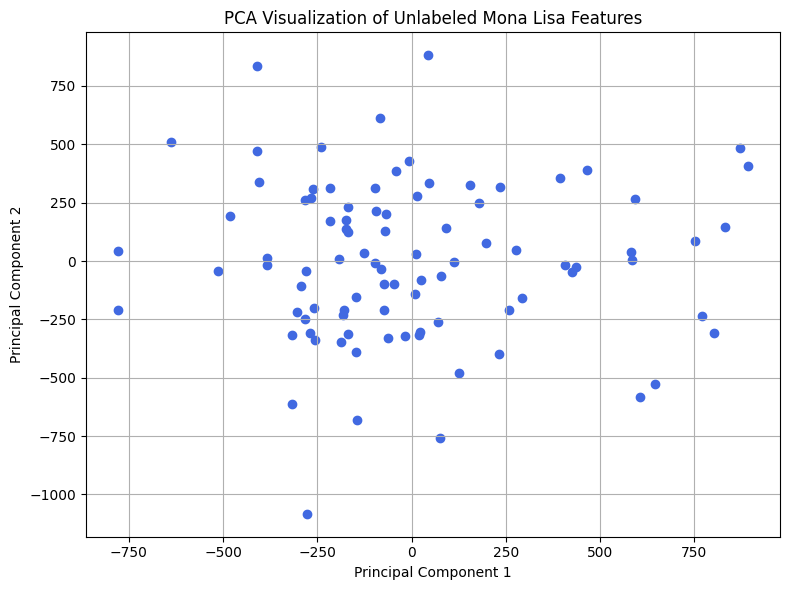

In [ ]:
# Further reduce to 2D for visualization only
visual_pca = PCA(n_components=2)
features_2d = visual_pca.fit_transform(selected_features_pca)

# Plot using Matplotlib

plt.figure(figsize=(8, 6))
plt.scatter(features_2d[:, 0], features_2d[:, 1], color='royalblue')
plt.title('PCA Visualization of Unlabeled Mona Lisa Features')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Combine all features (as before)
combined_features = np.hstack([color_features, orb_features, cnn_features])


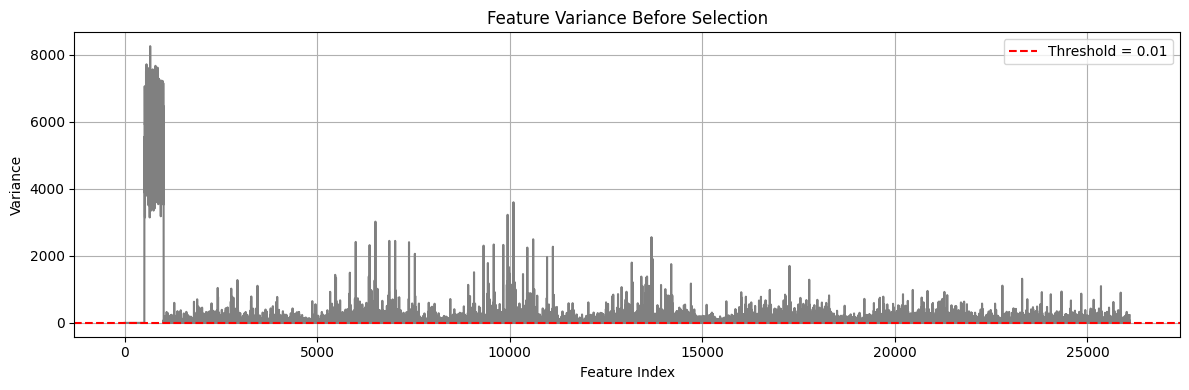

In [ ]:
# Calculate variance of each feature before selection
variances = np.var(combined_features, axis=0)

# Plot all variances
plt.figure(figsize=(12, 4))
plt.plot(variances, color='gray')
plt.axhline(y=0.01, color='red', linestyle='--', label='Threshold = 0.01')
plt.title("Feature Variance Before Selection")
plt.xlabel("Feature Index")
plt.ylabel("Variance")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Apply variance threshold
selector = VarianceThreshold(threshold=0.01)
selected_features = selector.fit_transform(combined_features)

# Get mask of selected features
mask = selector.get_support()
selected_variances = variances[mask]


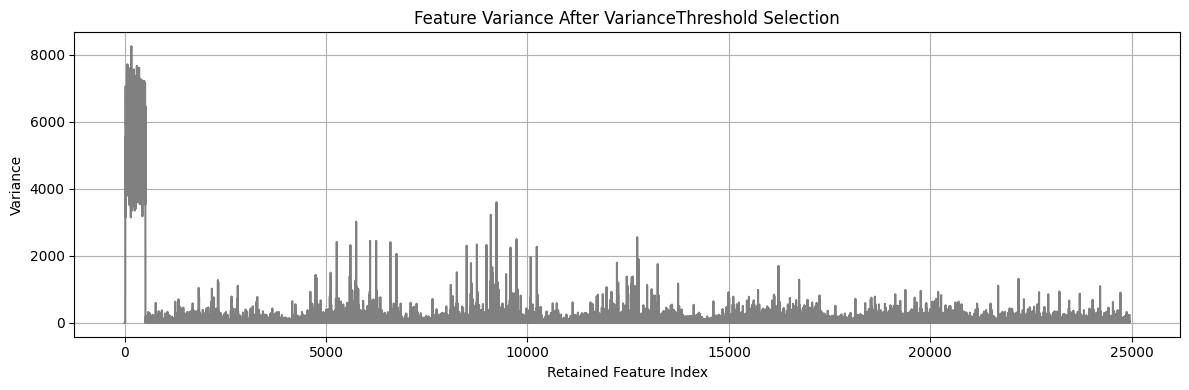

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(selected_variances, color='gray')
plt.title("Feature Variance After VarianceThreshold Selection")
plt.xlabel("Retained Feature Index")
plt.ylabel("Variance")
plt.grid(True)
plt.tight_layout()
plt.show()
